# Iterative methods for nonlinear equations

Given a function $f:I\to\mathbb{R}$, with $I\subset\mathbb{R}$, our goal is to find $\alpha\in I$ such that $f(\alpha)=0$.
Typical approaches to tackle this problem are _iterative_, meaning that we compute a sequence of numbers $\{x^{(k)}\}$ that (under suitable assumptions) converges to $\alpha$.

In particular, we will focus on the methods that were discussed during the lectures, namely:
1. Bisection method
2. Newton's method
3. Chord method
4. Secant method
5. Fixed point iterations

We will furthermore compare their performance in the case of a given nonlinear equation.

**Disclaimer**: here our aim is finding the zeros of $f$.
However, after understanding this machinery, it is straightforward consider the more general scenario to find $\beta$ such that

$$f(\beta)=c,$$
 
with given $c\in\mathbb{R}$.
Indeed, it suffices to define

$$g(x)=f(x)-c,$$

which has the same regularity of $f$: solving $f(\beta)=c$ is now equivalent to finding a zero of $g$, since
$$
g(\beta)=0\Longleftrightarrow  f(\beta)-c=0\Longleftrightarrow  f(\beta)=c.
$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sympy as sym

We imported Simpy since we will need to perform some symbolic computations, which we detail next.

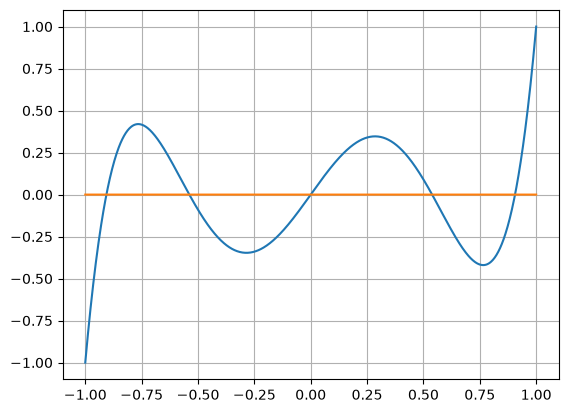

In [4]:
t = sym.symbols('t')

f_sym = t/8. * (63.*t**4 - 70.*t**2. +15.) # Legendre polynomial of order 5
f_prime_sym = sym.diff(f_sym,t)

f = sym.lambdify(t, f_sym, 'numpy')
f_prime = sym.lambdify(t,f_prime_sym, 'numpy') # Turn it into a function that can be evaluated on numpy arrays

# Otherwise you can just differentiate "by hand"
# def f(t):
#     return (t/8.0) * (63*t**4 - 70*t**2 + 15)

# def f_prime(t):
#     return (1/8.0) * (315*t**4 - 210*t**2 + 15)

# Consider three different functions for fixed point iteration
phi1 = lambda x : 63./70.*x**3 + 15./(70.*x)
phi2 = lambda x : 70.0/15.0*x**3 - 63.0/15.0*x**5
phi3 = lambda x : np.sqrt((63.*x**4 + 15.0)/70.)

# To plot:
n = 1025

x = np.linspace(-1,1,n)
c = np.zeros_like(x) # To highlight the points in which we have the roots

_ = plt.plot(x,f(x))
_ = plt.plot(x,c)
_ = plt.grid()

To compare the methodologies, we first need to set a few parameters:
1. An initial guess $x^{(0)}$ and, in the case of the secant method, $x^{(00)}$;
2. A tolerance $\varepsilon$. Notice that this could be employed in two different ways: either checking that $|x^{(k)}-x^{(k-1)}|<\varepsilon$ or $|f(x^{(k)})|<\varepsilon$;
3. A maximum number of iterations $n_\text{max}$, which defines our "computational budget" and after which the algorithm should stop.

We stop iterating when either the tolerance criterion is satisfied, or when $k>N_\text{max}$. Notice that, in the case in which we select $\varepsilon$ that is too restrictive, setting the maximum number of iteration prevents our algorithm to run for too long.

In [5]:
a = 0.75
b = 1.

# Initial guesses
x0 = (a+b)/2.0
x00 = b

# Stopping criteria
eps = 1e-10 # tolerance
n_max = 1000 # max number of iterations

## Bisection method
This method is arguably the easiest way to compute the roots of a function $f\in C^0([a,b])$, which only needs to be continuous.
The theorem of existence of zeros for continuous functions states that if $f \in C^0([a, b])$ and $f(a) f(b) < 0$, $f$ has at least one zero in $(a,b)$.
By iteratively bisecting the interval, we generate a sequence of nested intervals $\{[a^{(k)}, b^{(k)}]\}_{k=0}^\infty$ of exponentially decreasing length such that $\forall k, \alpha\in[a^{(k)}, b^{(k)}]$.

**Algorithm formulation**:
* **Inputs:** Function $f$, initial bracket $[a, b]$ with $f(a)f(b) < 0$, tolerance $\varepsilon > 0$, maximum iterations $n_{\max}$.
* **Initialization:**
  $$a^{(0)} = a, \quad b^{(0)} = b, \quad x^{(0)} = \frac{a^{(0)} + b^{(0)}}{2}, \quad e^{(0)} > \varepsilon, \quad k = 0$$
* **While $e^{(k)} > \varepsilon$ and $k < n_{\max}$:**
  1. Update the subinterval:
     * If $f(a^{(k)}) f(x^{(k)}) < 0$, set:
       $$a^{(k+1)} = a^{(k)}, \quad b^{(k+1)} = x^{(k)}$$
     * Else:
       $$a^{(k+1)} = x^{(k)}, \quad b^{(k+1)} = b^{(k)}$$
  2. Compute the new midpoint:
     $$x^{(k+1)} = \frac{a^{(k+1)} + b^{(k+1)}}{2}$$
  3. Estimate error:
     $$e^{(k+1)} = |x^{(k+1)} - x^{(k)}|$$
  4. Increment iteration index: $k \leftarrow k + 1$.

The true absolute error after $n$ iterations satisfies:
$$|x^{(n)} - \alpha| \le \frac{b - a}{2^{n+1}} = e^{(n)}$$

In [6]:
def bisect(f, a, b, eps, n_max):
    """
    Bisection method for finding a root of a continuous function on [a, b].

    Parameters
    ----------
    f : Callable[[float], float]
        The function for which we want to find a root.
    a : float
        Left endpoint of the interval.
    b : float
        Right endpoint of the interval.
    eps : float
        Stopping tolerance. The iteration stops when the error is <= eps.
    n_max : int
        Maximum number of iterations.

    Returns
    -------
    root : float
        Approximate root of f in [a, b].
    n_iter : int
        Number of iterations performed.
    errors : List[float]
        History of error estimates |x^{(k+1)} - x^{(k)}| at each iteration.

    Notes
    -----
    - The method assumes that f(a) and f(b) have opposite signs
      (i.e., the Intermediate Value Theorem guarantees a root).
    - Error is measured as the displacement between consecutive midpoints.
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    # Initialization of the new variables
    a_new, b_new = a, b
    x = (a + b) / 2.  # Initial midpoint approximation: x^(0)
    err = 1 + eps  # Set err > eps to guarantee entry into the loop
    errors = []  # Store history of errors across iterations
    it = 0

    while err > eps and it < n_max:
        # Check which half of the interval contains the root
        if f(a_new) * f(x) < 0:
            b_new = x  # Discard the right half
        else:
            a_new = x  # Discard the left half

        # Compute new midpoint: x^(k+1)
        x_new = (a_new + b_new) / 2.

        # Evaluate the error (three common choices in literature):
        # 1. Interval half-width: err = 0.5 * (b_new - a_new)
        # 2. Residual magnitude:  err = abs(f(x_new))
        # 3. Update magnitude:    err = abs(x_new - x)  <-- used here
        err = abs(x_new - x)
        errors.append(err)

        # Update values for next iteration
        x = x_new
        it += 1

    return x, it, errors

In [7]:
%time
[alpha, iters_bisect, errors_bisect] = bisect(f, a, b, eps, n_max)

print(fr"Root found: $alpha = {alpha:.12f}$ in {iters_bisect} iterations. We have that $|f(alpha)| = {abs(f(alpha)):.2e}$.")

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 3.34 μs
Root found: $alpha = 0.906179845973$ in 31 iterations. We have that $|f(alpha)| = 2.39e-10$.


In [8]:
def bisect(f, a, b, eps, n_max, store_midpoints=False):
    """
    Bisection method for finding a root of a continuous function on [a, b].

    Parameters
    ----------
    f : Callable[[float], float]
        The function for which we want to find a root.
    a : float
        Left endpoint of the interval.
    b : float
        Right endpoint of the interval.
    eps : float
        Stopping tolerance. The iteration stops when the error is <= eps.
    n_max : int
        Maximum number of iterations.
    store_midpoints : bool, optional
        If True, store the midpoints at each iteration.

    Returns
    -------
    root : float
        Approximate root of f in [a, b].
    n_iter : int
        Number of iterations performed.
    errors : List[float]
        History of error estimates |x^{(k+1)} - x^{(k)}| at each iteration.
    midpoints : List[float], optional
        History of midpoints at each iteration.

    Notes
    -----
    - The method assumes that f(a) and f(b) have opposite signs
      (i.e., the Intermediate Value Theorem guarantees a root).
    - Error is measured as the displacement between consecutive midpoints.
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    a_new, b_new = a, b
    x = (a + b) / 2.0
    errors = []
    midpoints = [x] if store_midpoints else None
    it = 0

    while it < n_max:
        if f(a_new) * f(x) < 0:
            b_new = x
        else:
            a_new = x

        # Compute new midpoint: x^(k+1)
        x_new = (a_new + b_new) / 2.0

        err = abs(x_new - x)
        errors.append(err)

        x = x_new
        if store_midpoints:
            midpoints.append(x)
        it += 1
        
        if err <= eps:
            break

    if store_midpoints:
        return x, it, errors, midpoints
    return x, it, errors

In [9]:
%time
[alpha, iters_bisect, errors_bisect, mids] = bisect(f, a, b, eps, n_max, store_midpoints=True)

print(fr"Root found: $\alpha = {alpha:.12f}$ in {iters_bisect} iterations. We have that $|f(\alpha)| = {abs(f(alpha)):.2e}$.")

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 3.1 μs
Root found: $\alpha = 0.906179845973$ in 31 iterations. We have that $|f(\alpha)| = 2.39e-10$.


In [10]:
import matplotlib.animation as animation
from IPython.display import HTML

# Plot setup
fig, ax = plt.subplots()
x_vals = np.linspace(a, b, 400)
ax.plot(x_vals, f(x_vals), label="f(x)")
ax.axhline(0, color="black", linewidth=1)
point, = ax.plot([], [], "ro", label="Midpoint")
plt.grid()
plt.legend()

def init():
    point.set_data([], [])
    return (point,)

def update(i):
    x = mids[i]
    point.set_data([x], [f(x)])
    return (point,)

# Create animation
ani = animation.FuncAnimation(
    fig, update, frames=len(mids),
    init_func=init, blit=True, interval=800, repeat=False
)

plt.close(fig)

# Display in Jupyter / Colab
HTML(ani.to_jshtml())

Bisection found root 0.9061798459733836 in 31 iterations.
Residual on approximate solution is 2.38535626354048e-10


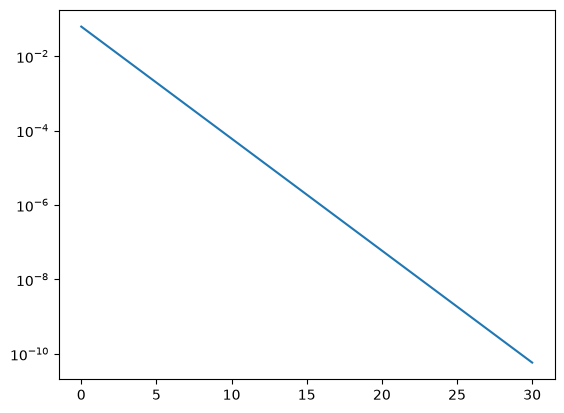

In [11]:
print("Bisection found root", alpha, "in", iters_bisect, "iterations.")
print("Residual on approximate solution is", abs(f(alpha)))

plt.semilogy(errors_bisect)

### Estimate the number of iterations
We notice that, at each iteration $k$ of the bisection method, the root $\alpha$ is contained in the current interval $[a^{(k)}, b^{(k)}]$.
As a result,

$$e^{(k)}=|x^{(k)} - \alpha| \le \frac{b^{(k)} - a^{(k)}}{2} = \frac{b - a}{2^{k+1}}.$$

Therefore, if an accuracy $\varepsilon > 0$ is desired, can impose the following upper bound:

$$|x^{(k)} - \alpha| \le \frac{b - a}{2^{k+1}} \le \varepsilon$$

Solving for the number of iterations $k_\varepsilon$ necessary to satisfy the previous relation, we obtain

$$
\frac{b - a}{\varepsilon} \leq 2^{k_\varepsilon+1},
$$ 

i.e.

$$
k_\varepsilon\geq \log_2(\frac{b-a}{\varepsilon})-1
$$.

In [12]:
it_theor = (np.log(np.abs(b-a)) - np.log(eps))/np.log(2)
print(f"Predicted number of iterations: {it_theor}")

Predicted number of iterations: 31.219280948873624


The good thing about bisection is that it is _robust_, as it always converges to a zero of $f$.
However, convergence is slow: as a result, a common approach entails first running a few bisection iterations to approximatively localize the root, and then switching to more powerful schemes, such as Newton's method, which we introduce next.

## Newton's method
In order to derive alternative methods for solving nonlinear equations, let us consider a function $f \in C^1([a, b])$ and compute its first-order Taylor expansion around the current estimate $x^{(k)}$:

$$f(x) \approx h(x) = f(x^{(k)}) + f'(x^{(k)})(x - x^{(k)}),$$

meaning that we are substituting $f$ with its linear approximant $h$.
As a result, instead of seeking a root $\alpha$ such that $f(\alpha) = 0$, we seek a zero of $h$, i.e., we look for $\alpha$ such that

$$f(\alpha)\approx h(\alpha) = f(x^{(k)}) + f'(x^{(k)})(\alpha - x^{(k)})=0.$$

Solving for $\alpha$ provides a candidate for the next approximation $x^{(k+1)}$:

$$x^{(k+1)} = x^{(k)} - \frac{f(x^{(k)})}{f'(x^{(k)})}.$$


Summarizing, the whole procedure reads as follows:

**Algorithm formulation**:
* **Inputs:** Function $f$, derivative $f'$, initial guess $x^{(0)}$, tolerance $\varepsilon > 0$, maximum iterations $n_{\max}$, derivative threshold $\delta > 0$.
* **Initialization:**
  $$x^{(0)} = x_0, \quad e^{(0)} > \varepsilon, \quad k = 0$$
* **While $e^{(k)} > \varepsilon$ and $k < n_{\max}$:**
  1. Check the derivative:
     $$\text{If } |f'(x^{(k)})| < \delta, \quad \text{terminate with failure}$$
  2. Compute the update:
     $$x^{(k+1)} = x^{(k)} -\frac{f(x^{(k)})}{f'(x^{(k)})}$$
  3. Estimate error:
     $$e^{(k+1)} = |x^{(k+1)} - x^{(k)}| = |\Delta x^{(k)}|$$
  4. Increment iteration index: $k \leftarrow k + 1$.

If $f \in C^2$ and $f'(\alpha) \ne 0$, then for $x^{(0)}$ sufficiently close to $\alpha$, the sequence converges quadratically:
$$\lim_{k \to \infty} \frac{|x^{(k+1)} - \alpha|}{|x^{(k)} - \alpha|^2} = \frac{|f''(\alpha)|}{2|f'(\alpha)|}$$

In [24]:
def newton(f, f_prime, x0, eps=1e-8, n_max=100):
    """
    Newton's method for finding a root of a real-valued function.

    Parameters
    ----------
    f : Callable[[float], float]
        Function whose root we want to approximate.
    f_prime : Callable[[float], float]
        Derivative of f.
    x0 : float
        Initial guess for the root.
    eps : float, optional (default=1e-8)
        Stopping tolerance. The iteration stops when |x^(k+1) - x^(k)| <= eps.
    n_max : int, optional (default=100)
        Maximum number of iterations.

    Returns
    -------
    root : float
        Approximate root of f.
    n_iter : int
        Number of iterations performed.
    errors : List[float]
        History of step displacements |x^(k+1) - x^(k)| at each iteration.

    Notes
    -----
    - Newton's method exhibits quadratic convergence locally when f'(alpha) != 0.
    - If f'(x) is close to zero, the method may stall or diverge.
    """
    x = x0
    errors = []
    it = 0
    err = eps + 1

    tol_deriv = 1e-12 # to ensure the absolute value of the derivative is not too small

    while err > eps and it < n_max:
        # fx = f(x) # we should actually pre-compute it here and use it in the next lines to avoid double evaluation.
                    # we are not doing that here to keep the code simple in the lab. When writing real world code, it
                    # is a good practice to avoid double evaluation of the same function. Same in the other methods

        qk = f_prime(x)

        if abs(qk) < tol_deriv:
            raise RuntimeError(f"Derivative too close to zero (|f'({x:.6e})| = {abs(qk):.2e}) at iteration {it}.")
        
        x_new = x - f(x) / qk # Newton update step: dx = - f(x) / f'(x)

        # Error estimate via step displacement: |x^(k+1) - x^(k)|
        err = abs(x_new - x)
        errors.append(err)

        # Advance state
        x = x_new
        it += 1

    return x, it, errors

In [25]:
%time
[alpha, iters_newton, errors_newton] = newton(f, f_prime, 1.0, eps, n_max)

CPU times: user 1 μs, sys: 0 ns, total: 1 μs
Wall time: 4.05 μs


Newton found root 0.906179845938664 in 6 iterations.
Residual on approximate solution is 0.0


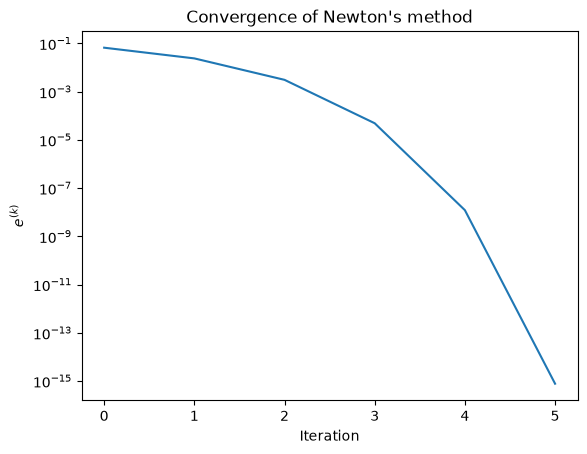

In [26]:
print("Newton found root", alpha, "in", iters_newton, "iterations.")
print("Residual on approximate solution is", np.abs(f(alpha)))
plt.semilogy(errors_newton)
plt.xlabel("Iteration")
plt.ylabel(r"$e^{(k)}$")
plt.title("Convergence of Newton's method")
plt.show()

**Question:**
But what is the meaning of quadratic convergence in practice?
Let us look at the output (and not the code) of the following cell.

In [49]:
##########################################################################################
###### FORGET ABOUT THIS PART FOR THE PURPOSES OF THE LAB. JUST LOOK AT THE OUTPUT! ######
##########################################################################################

def newton_with_history(f, f_prime, x0, eps=1e-8, n_max=100):
    """
    Just to save also the history. Do not refer to this implementation, just for practical purposes.
    """
    x = x0
    history = [x]
    it = 0
    err = eps + 1
    tol_deriv = 1e-12

    while err > eps and it < n_max:
        qk = f_prime(x)
        if abs(qk) < tol_deriv:
            raise RuntimeError(f"Derivative too close to zero at iteration {it}.")

        x_new = x - f(x) / qk
        err = abs(x_new - x)

        x = x_new
        history.append(x)
        it += 1

    return x, it, history


def print_digit_convergence(iterates, precision=16):
    """
    DISCLAIMER: I admit not writing this code. Thanks Gemini for being so kind to me. 
    Prints the iterative sequence, highlighting matching prefix digits

    with the previous iteration in green and counting the matching digits.

    Parameters
    ----------
    iterates : List[float]
        Sequence of approximations [x^(0), x^(1), ..., x^(N)].
    precision : int, optional (default=16)
        Number of decimal digits to display.
    """
    GREEN = "\033[92m"
    RESET = "\033[0m"

    print(
        f"{'Iter'} | {'Approximation':<{precision + 8}} | {'Fixed digits'}"
    )
    print("-" * (precision + 32))

    prev_str = None

    for k, val in enumerate(iterates):
        curr_str = f"{val:.{precision}f}"

        if prev_str is None:
            # First iterate (x0): no previous comparison available
            print(f"{k:<5} | {curr_str:<{precision + 8}} | {'-':<13}")
        else:
            # Find the longest matching prefix
            match_idx = 0
            while (
                match_idx < len(curr_str)
                and match_idx < len(prev_str)
                and curr_str[match_idx] == prev_str[match_idx]
            ):
                match_idx += 1

            # Count only digit characters that match (exclude the decimal point)
            matched_digits_count = sum(
                1 for ch in curr_str[:match_idx] if ch.isdigit()
            )

            # Build colorized output
            colored_str = (
                f"{GREEN}{curr_str[:match_idx]}{RESET}{curr_str[match_idx:]}"
            )

            # Extra padding accounts for ANSI escape character bytes in the terminal
            ansi_offset = len(GREEN) + len(RESET)
            print(
                f"{k:<5} | {colored_str:<{precision + 8 + ansi_offset}} | {matched_digits_count:<13}"
            )

        prev_str = curr_str


alpha, iters, history = newton_with_history(f, f_prime, x0=1.0, eps=1e-14)

print_digit_convergence(history)

Iter | Approximation            | Fixed digits
------------------------------------------------
0     | 1.0000000000000000       | -            
1     | 0.9333333333333333       | 0            
2     | 0.9093264322119011       | 2            
3     | 0.9062289457968719       | 3            
4     | 0.9061798581501155       | 4            
5     | 0.9061798459386647       | 8            
6     | 0.9061798459386640       | 16           


You see that at each iteration the number of digits that stays unchanged approximately doubles!

## Chord method
Since evaluating $f'$ at each iteation is often computationally demanding in real-world applications, we can consider a more general family of methodologies in which, for each $k$, we substitute $f'(x^{(k)})$ by $q(x^{(k)})\approx f'(x^{(k)})$.

In the chord method, for example, we choose

$$
q^{(k)} = q = \frac{f(b)- f(a)}{b-a},\quad\forall k,
$$

so that

$$
x^{(k+1)} = x^{(k)}-\frac{f(x^{(k)})}{q}.
$$

Since we are being less accurate in the computation of the derivative, we expect a lower order of convergence, and it is indeed the case.

In [ ]:
def chord(f, a, b, x0, eps=1e-6, n_max=100):
    """
    Chord method for finding a root of f(x) using a fixed secant slope.

    Parameters
    ----------
    f : Callable[[float], float]
        Function whose root is sought.
    a, b : float
        Interval endpoints used to calculate the fixed slope q.
    x0 : float
        Initial guess.
    eps : float, optional (default=1e-6)
        Stopping tolerance based on consecutive iterate displacement.
    n_max : int, optional (default=100)
        Maximum number of iterations.

    Returns
    -------
    root : float
        Approximated root.
    n_iter : int
        Number of iterations performed.
    errors : List[float]
        History of error estimates |x^(k+1) - x^(k)| at each iteration.

    Notes
    -----
    - The slope q = (f(b) - f(a)) / (b - a) remains constant for all iterations.
    - Convergence is linear, provided 0 < f'(alpha) / q < 2 near the root.
    """
    # Compute constant slope
    q = (f(b) - f(a)) / (b - a)

    tol_slope = 1e-14  # Minimum absolute value allowed for the constant slope q
    if abs(q) < tol_slope:
        raise ValueError(f"Slope q is too close to zero (|q| = {abs(q):.2e}); method will fail.")

    x = x0
    errors = []
    it = 0
    err = eps + 1.0

    while err > eps and it < n_max:
        x_new = x - f(x) / q  # Fixed slope update
        dx = x_new - x

        # Step error
        err = abs(dx)
        errors.append(err)

        # Advance state
        x = x_new
        it += 1

    return x, it, errors

Chords found root 0.9061798459469729 in 13 iterations.
Residual on approximate solution is 5.70847473767655e-11


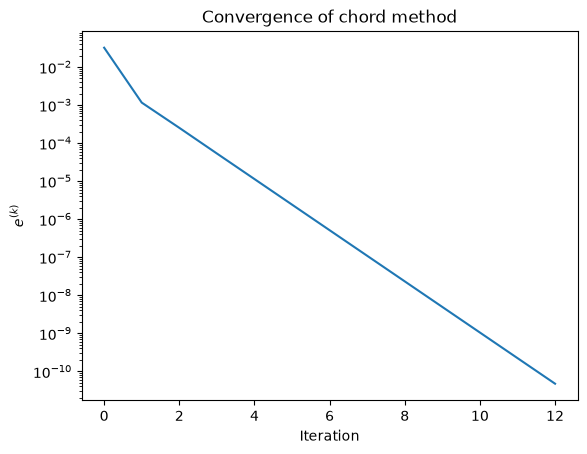

In [41]:
[alpha, iters_chord, errors_chords] = chord(f, a, b, x0, eps, n_max)
print("Chords found root", alpha,"in", iters_chord, "iterations.")
print("Residual on approximate solution is", abs(f(alpha)))
plt.semilogy(errors_chords)
plt.xlabel("Iteration")
plt.ylabel(r"$e^{(k)}$")
plt.title("Convergence of chord method")
plt.show()

## Secant method
Similar to before, but now we approximate $q^{(k)}$ at each step using the incremental ratio of $f$ between two successive iterations, i.e.,

$$
q^{(k)}=\frac{f(x^{(k)})-f(x^{(k-1)})}{x^{(k)}-x^{(k-1)}}
$$

and then

$$
x^{(k+1)} = x^{(k)}-\frac{f(x^{(k)})}{q^{(k)}}.
$$

Compared to Newton, the accuracy of the derivative is lower, but we are still doing better than the chord method.
Notice that, in this scenario, we need **two** different initial guesses.

In [50]:
def secant(f, x0, x00, eps, n_max):
    """
    Implementation of the secant method to find a root of a function f(x).

    Parameters:
        f      : callable
                 The function whose root is to be found.
        x0     : float
                 The first initial guess for the root.
        x00    : float
                 The second initial guess for the root.
        eps    : float
                 Desired accuracy; the iteration stops when the absolute change 
                 between consecutive approximations is less than eps.
        n_max  : int
                 Maximum number of iterations allowed.

    Returns:
        xk     : float
                 The approximated root of the function.
        it     : int
                 The number of iterations performed.
        errors : list of float
                 List of absolute errors at each iteration 
                 (|x_new - x_old|).
    """
    err = eps + 1.
    errors = []
    it = 0
    xk = x0
    xkk = x00

    while (err > eps and it < n_max):
        # here we skip all the checks on the incremental ratio: by now you know the drill
        qk = (f(xk) - f(xkk))/(xk - xkk)
        x_new = xk - f(xk)/qk
        err = abs(x_new - xk)
        xkk = xk
        xk = x_new
        errors.append(err)
        it += 1
    return xk, it, errors

Secant found root 0.906179845938664 in 7 iterations.
Residual on approximate solution is 0.0


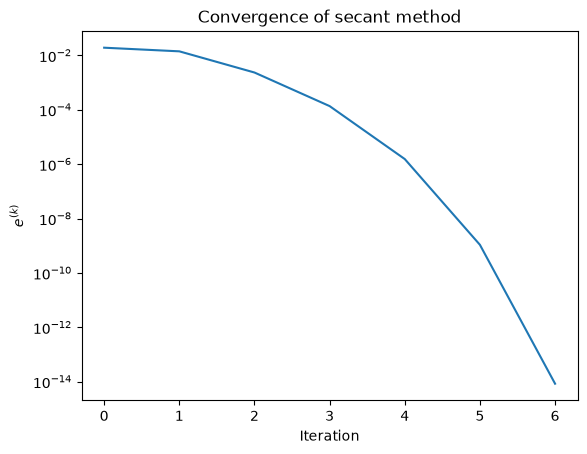

In [51]:
[alpha, iters_secant, errors_secant] = secant(f, x0, x00, eps, n_max)
print("Secant found root", alpha, "in", iters_secant, "iterations.")
print("Residual on approximate solution is", abs(f(alpha)))
plt.semilogy(errors_secant)
plt.xlabel("Iteration")
plt.ylabel(r"$e^{(k)}$")
plt.title("Convergence of secant method")
plt.show()

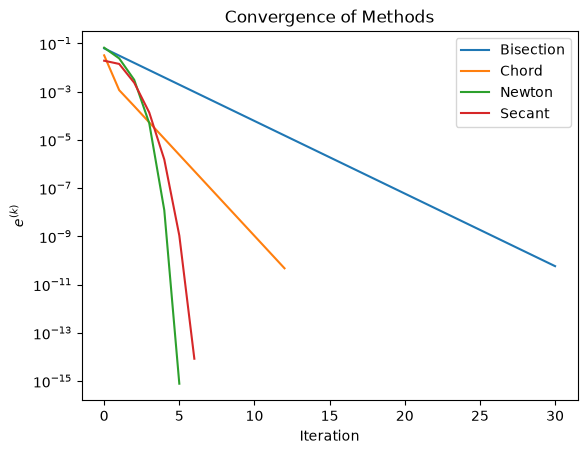

In [ ]:
plt.semilogy(errors_bisect, label='Bisection')
plt.semilogy(errors_chords, label='Chord')
plt.semilogy(errors_newton, label ='Newton')
plt.semilogy(errors_secant, label='Secant')
plt.xlabel("Iteration")
plt.ylabel(r"$e^{(k)}$")
plt.title("Convergence of methods (semilogy scale)")
plt.legend()
plt.show()

You see that bisection is the slowest method in terms of convergence.
The secant and chord method provide a good trade-off between speed and accuracy, especially in the case of the secant method!

Incidentally, in the previous plot you can see that the chord method is represented by a straighy line in semilog plot (as it has order one), whereas Newton (order 2) follows a parabula.

Just for comparison, here is what finding roots of a function looks like using SciPy:

In [60]:
import scipy.optimize as opt
%time alpha = opt.newton(f, 1.0, f_prime, tol = eps)
print("Scipy's Newton found root", alpha)

CPU times: user 207 μs, sys: 10 μs, total: 217 μs
Wall time: 220 μs
Scipy's Newton found root 0.906179845938664


**For Machine Learning (ML) practitioners (not needed for the exam)**: in ML, we have a model (typically a neural network) that depends on a set of parameters $\bm\theta$.
To train a model starting from some data $\{x^{(i)}\}_{i=1}^n$,

# TODO:
- add fixed point iteration
- add LBFGS explanation 